In [83]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets
from torch.utils.data import DataLoader
from src.augmentation import train_transform, test_val_transform
from torch.utils.data import Subset

In [84]:
sys.path.append(os.path.abspath("..")) # For Python path resolution problem
from src.data_loader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(batch_size=32)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

 Data Loaders Ready
Classes: ['WithMask', 'WithoutMask']
Train batches: 312
Validation batches: 25
Test batches: 31


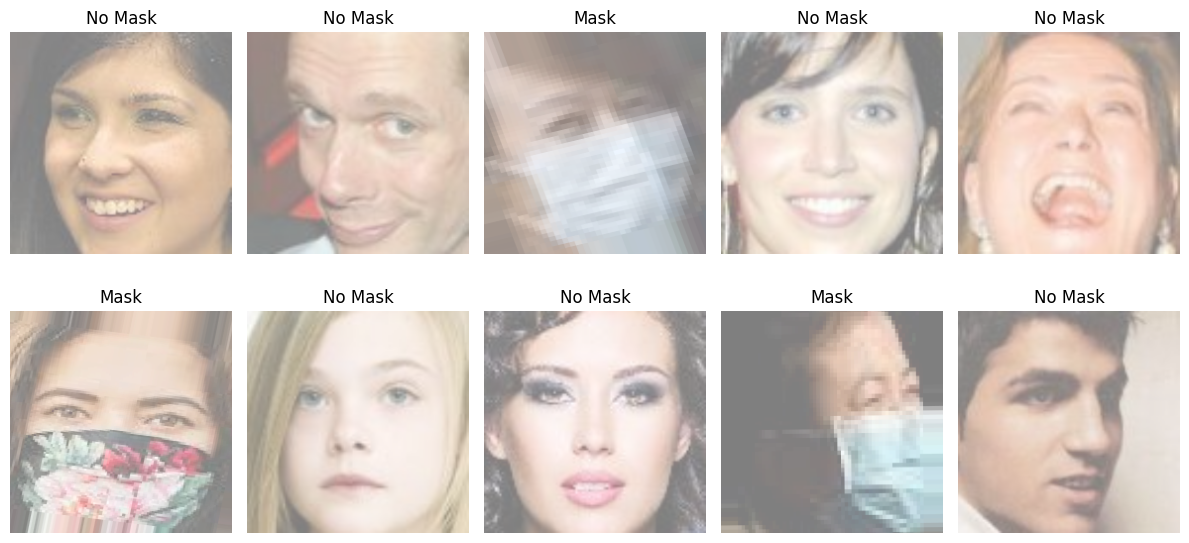

In [85]:
# This cell displays random one batch of training images in a grid.

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)  # CHW → HWC
    img = img * 0.5 + 0.5  # unnormalize (because Normalize([0.5],[0.5]))

    ax.imshow(img)
    ax.set_title("Mask" if labels[i].item() == 0 else "No Mask")
    ax.axis("off")

plt.tight_layout()
plt.show()

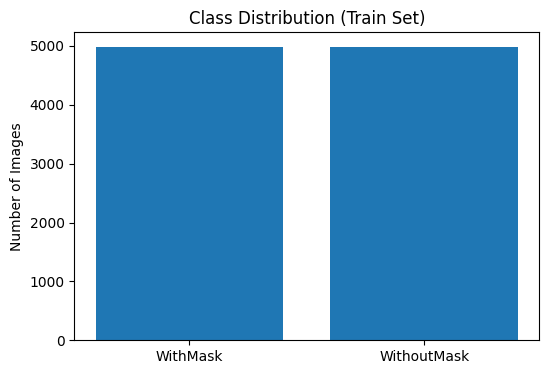

In [86]:
# This cell checks if dataset is balanced or biased toward one class.

train_path = "../data/Train"

classes = ["WithMask", "WithoutMask"]

counts = [
    len(os.listdir(os.path.join(train_path, c)))
    for c in classes
]

plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Class Distribution (Train Set)")
plt.ylabel("Number of Images")
plt.show()

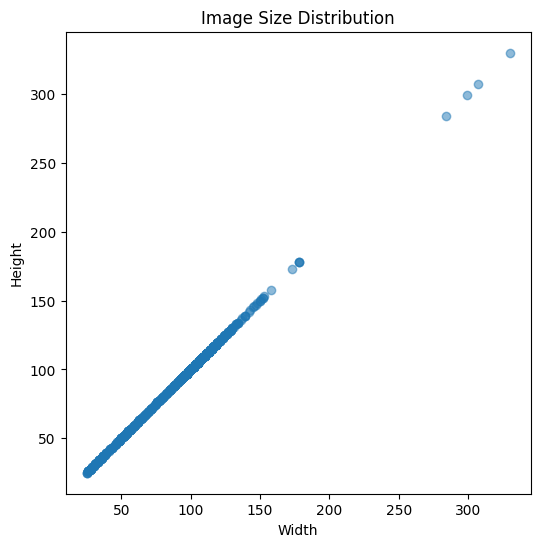

In [87]:
# This cell checks whether images have consistent dimensions or vary a lot.

train_path = "../data/Train"
classes = ["WithMask", "WithoutMask"]

widths = []
heights = []

for cls in classes:
    folder = os.path.join(train_path, cls)
    
    for img_name in os.listdir(folder)[:500]:  # sample for speed
        img = Image.open(os.path.join(folder, img_name))
        w, h = img.size
        
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.5)
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

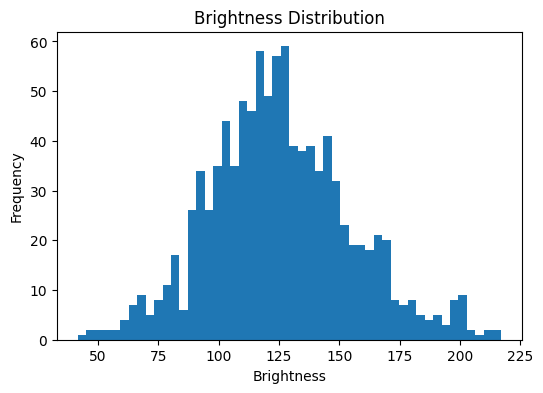

In [88]:
# Plots brightness distribution of training images to check lighting conditions.

train_path = "../data/Train"
classes = ["WithMask", "WithoutMask"]

brightness_values = []

for cls in classes:
    folder = os.path.join(train_path, cls)
    
    for img_name in os.listdir(folder)[:500]:
        img = cv2.imread(os.path.join(folder, img_name))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness_values.append(np.mean(gray))

plt.figure(figsize=(6,4))
plt.hist(brightness_values, bins=50)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

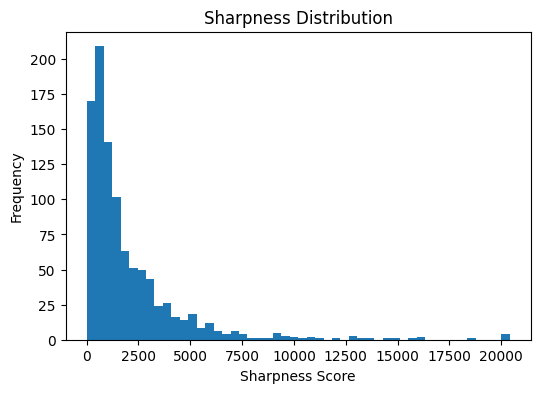

In [89]:
# Analyzes image sharpness using Laplacian variance to detect blurry images

train_path = "../data/Train"
classes = ["WithMask", "WithoutMask"]

sharpness = []

for cls in classes:
    folder = os.path.join(train_path, cls)

    for img_name in os.listdir(folder)[:500]:
        img = cv2.imread(os.path.join(folder, img_name), 0)
        score = cv2.Laplacian(img, cv2.CV_64F).var()
        sharpness.append(score)

plt.figure(figsize=(6,4))
plt.hist(sharpness, bins=50)
plt.title("Sharpness Distribution")
plt.xlabel("Sharpness Score")
plt.ylabel("Frequency")
plt.show()

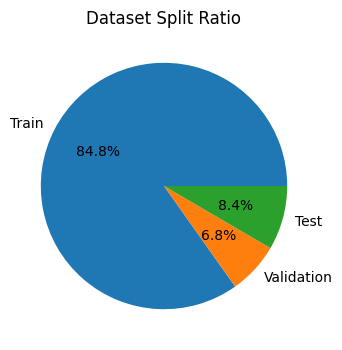

In [90]:
# Visualizes dataset split ratios across Train, Validation, and Test folders

splits = ["Train", "Validation", "Test"]
classes = ["WithMask", "WithoutMask"]

values = []

for split in splits:
    total = 0
    
    for cls in classes:
        path = os.path.join(f"../data/{split}", cls)
        total += len(os.listdir(path))
    
    values.append(total)

plt.figure(figsize=(6,4))
plt.pie(values, labels=splits, autopct='%1.1f%%')
plt.title("Dataset Split Ratio")
plt.show()

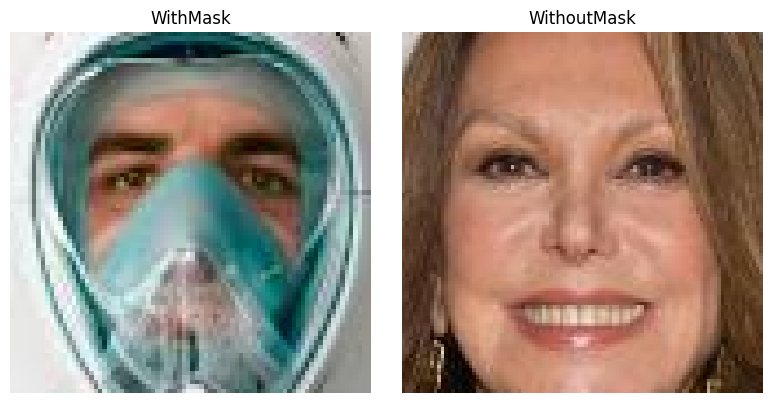

In [91]:
# Displays one random sample image per class for visual comparison

train_path = "../data/Train"
classes = ["WithMask", "WithoutMask"]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    img_name = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, img_name))

    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [92]:
# Summarizes dataset quality insights from all EDA visualizations

print("========== DATASET EDA SUMMARY ==========\n")

print("1. Class Balance:")
print("- Check bar chart for WithMask vs WithoutMask distribution\n")

print("2. Image Quality:")
print("- Brightness distribution shows lighting variation (normal for real-world data)")
print("- Sharpness distribution shows most images are usable, with few blurry samples\n")

print("3. Image Structure:")
print("- Image sizes vary in raw dataset but are standardized to 224x224 in preprocessing\n")

print("4. Dataset Split:")
print("- Train/Validation/Test split is consistent and properly structured\n")

print("5. Visual Inspection:")
print("- Sample images confirm clear distinction between Mask and No Mask classes\n")

print("\nFINAL CONCLUSION:")
print("Dataset is suitable for training a deep learning classification model with good generalization potential.")

========== DATASET EDA SUMMARY ==========

1. Class Balance:
- Check bar chart for WithMask vs WithoutMask distribution

2. Image Quality:
- Brightness distribution shows lighting variation (normal for real-world data)
- Sharpness distribution shows most images are usable, with few blurry samples

3. Image Structure:
- Image sizes vary in raw dataset but are standardized to 224x224 in preprocessing

4. Dataset Split:
- Train/Validation/Test split is consistent and properly structured

5. Visual Inspection:
- Sample images confirm clear distinction between Mask and No Mask classes


FINAL CONCLUSION:
Dataset is suitable for training a deep learning classification model with good generalization potential.


In [93]:
# Performs final sanity check of dataset readiness for model training

corrupt_count = 0

for split in ["Train", "Validation", "Test"]:
    for cls in ["WithMask", "WithoutMask"]:
        folder = os.path.join(f"../data/{split}", cls)

        for img_name in os.listdir(folder):
            try:
                img = Image.open(os.path.join(folder, img_name))
                img.verify()
            except:
                corrupt_count += 1

print("========== FINAL DATASET CHECK ==========")
print(f"Corrupted images found: {corrupt_count}")

if corrupt_count == 0:
    print("Dataset is CLEAN and READY for training.")
else:
    print("Dataset has issues that should be reviewed.")

========== FINAL DATASET CHECK ==========
Corrupted images found: 0
Dataset is CLEAN and READY for training.


##  Data Augmentation Visualizer**

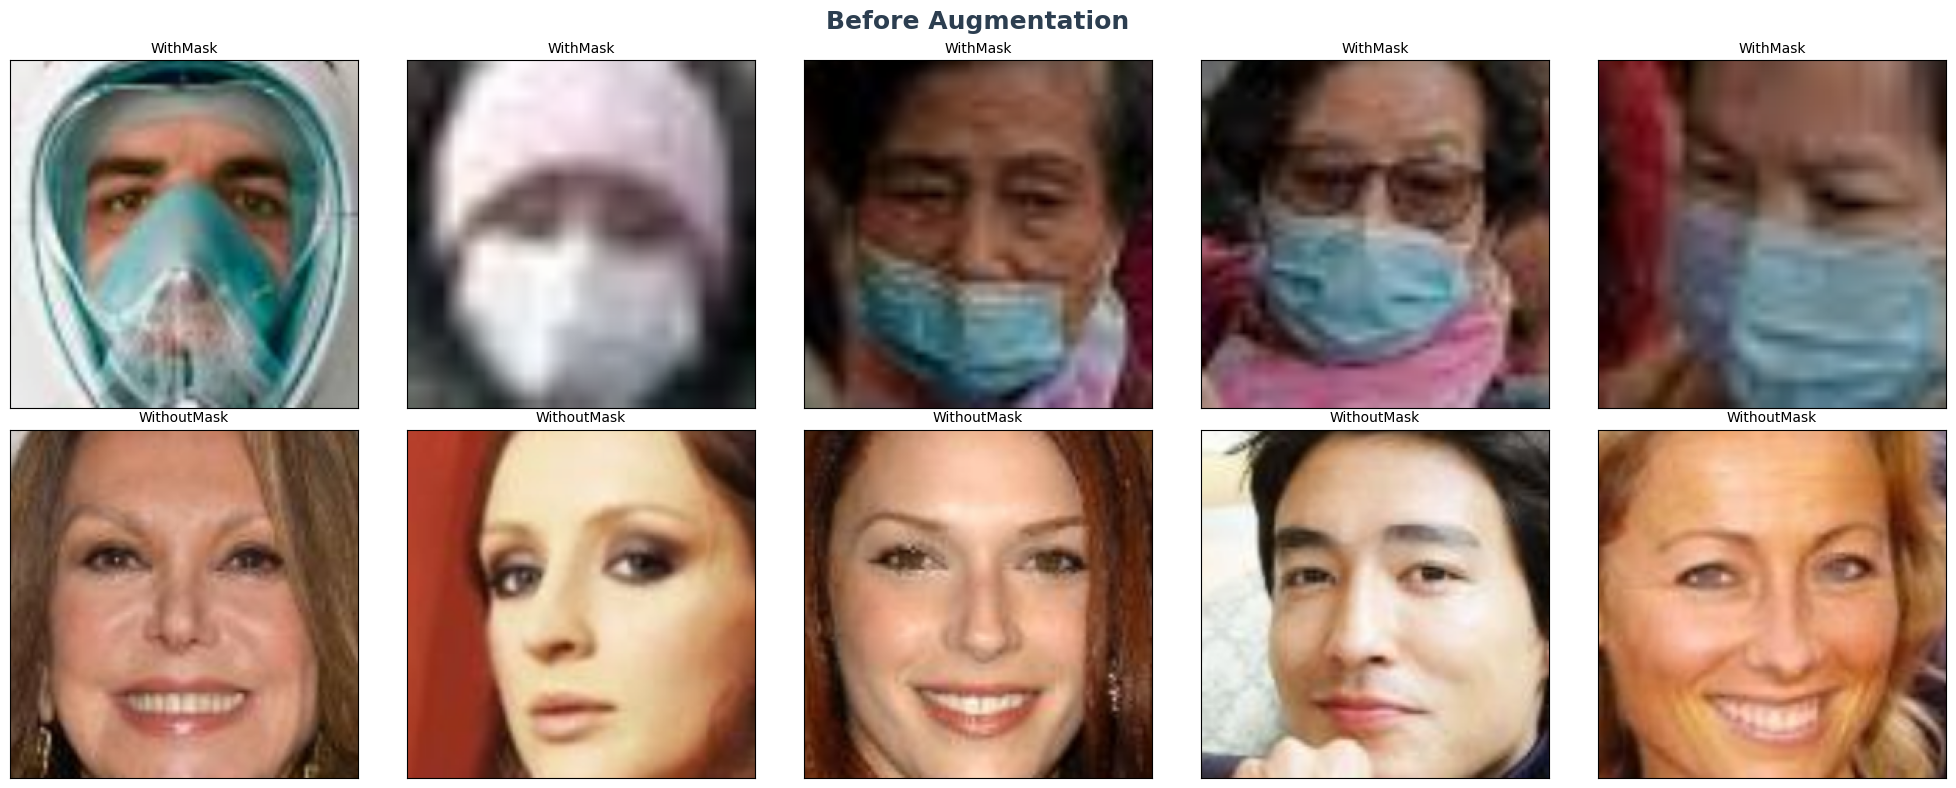

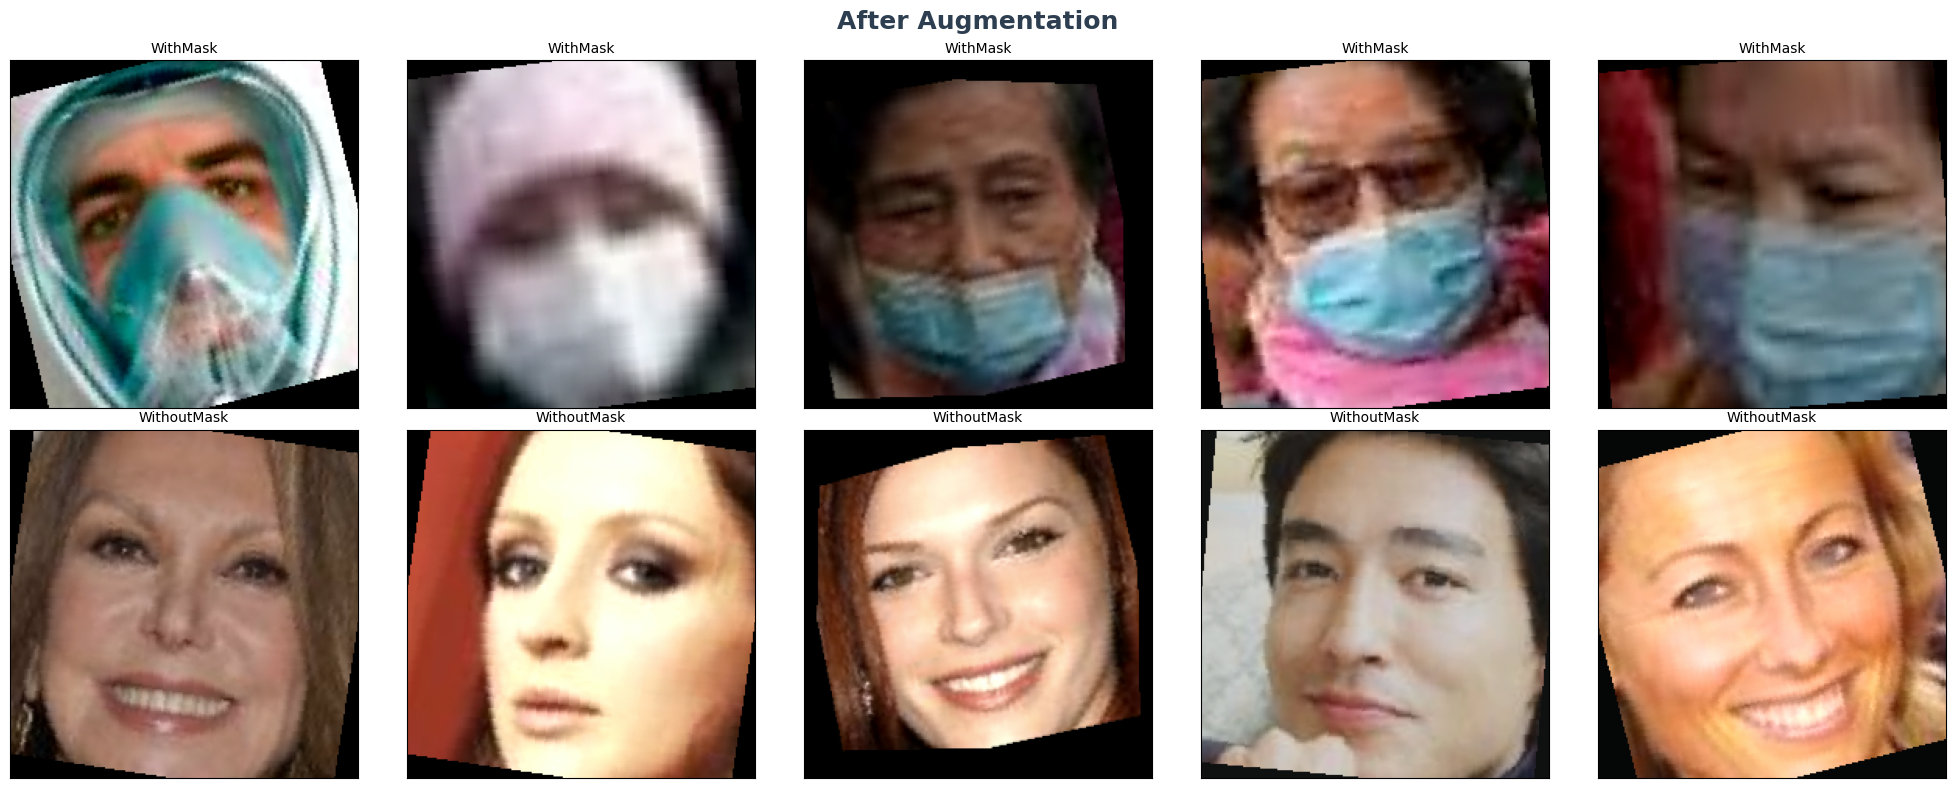

In [117]:
DATA_PATH = "../data"

def im_convert(tensor):
    image = tensor.cpu().numpy()
    image = image.transpose(1, 2, 0)
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))
    image = image.clip(0, 1)
    return image

def plot_images(images, labels, title, save_path):
    fig = plt.figure(figsize=(20, 8))
    fig.suptitle(title, fontsize=18, fontweight='bold', color='#2c3e50')
    for idx in np.arange(10):
        ax = fig.add_subplot(2, 5, idx+1, xticks=[], yticks=[])
        plt.imshow(im_convert(images[idx]))
        ax.set_title(CLASSES[labels[idx].item()].replace('_', ' '), fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

basic_dataset = datasets.ImageFolder(root=f"{DATA_PATH}/Train", transform=test_val_transform)
aug_dataset   = datasets.ImageFolder(root=f"{DATA_PATH}/Train", transform=train_transform)

CLASSES = basic_dataset.classes

targets = np.array(basic_dataset.targets)
with_mask_idx    = np.where(targets == 0)[0][:5].tolist()
without_mask_idx = np.where(targets == 1)[0][:5].tolist()
indices = with_mask_idx + without_mask_idx

basic_loader = DataLoader(Subset(basic_dataset, indices), batch_size=10, shuffle=False)
aug_loader   = DataLoader(Subset(aug_dataset,   indices), batch_size=10, shuffle=False)

basic_images, basic_labels = next(iter(basic_loader))
aug_images,   aug_labels   = next(iter(aug_loader))

plot_images(basic_images, basic_labels, "Before Augmentation", "../reports/before_augmentation.png")
plot_images(aug_images,   aug_labels,   "After Augmentation",  "../reports/after_augmentation.png")